# Linear probes on the residual channel

The model was trained on an **incomplete** CUB attribute set: `num_concepts` attributes survived, the rest were deleted before training and the encoder never saw them. For each deleted attribute `a` we ask how much of it can be linearly decoded back out of the saved `c_mu` / `res_mu` dumps.

A probe is a deliberately weak model. The network is frozen, its activations are the input, and a logistic regression is all that stands between them and the answer. The weakness is the point: a sufficiently expressive probe extracts almost anything from almost any representation, including from random features, so only linearity makes the answer meaningful. If a linear map recovers `has_wing_color::black` from residual 45, that information is present in a form the downstream linear head could actually use.

The information direction matters too. The 90 removed attributes were never a training signal. If a residual decodes one, the encoder learned that visual property on its own, from the classification loss alone, because it helped tell birds apart.

**The four probes**

| # | input | question |
|---|---|---|
| 1 | `res_mu[:, j]` | Is residual *j*, by itself, a detector for attribute *a*? |
| 2 | `res_mu` | Is *a* encoded in the residual channel at all, even if spread across dimensions? |
| 3 | `c_mu` | Could you have predicted *a* without looking at the residuals? **The control.** |
| 4 | `[c_mu, res_mu]` | What do the residuals add on top of the observed bottleneck? |

Probe 1 is the strongest form of the interpretability claim — one named dimension, one named concept. Probe 2 is weaker but more permissive; distributed encoding is the common case, so it will usually beat probe 1 substantially. If probe 2 is high while probe 1 sits at chance for every residual, the information is there but polysemantic, which argues for in-training sparsity over post-hoc decomposition.

Probe 3 does the most work. CUB attributes are heavily correlated — birds with dagger bills share plumage patterns, and `has_bill_shape::dagger` is in the kept set — so a removed attribute might be predictable at AUC 0.85 from the kept concepts alone, and a residual "decoding" it would be telling us nothing new. Without this baseline probes 1 and 2 are uninterpretable.

$$\texttt{residual\_increment} = \mathrm{AUC}(\texttt{concepts} + \texttt{residuals}) - \mathrm{AUC}(\texttt{concepts})$$

is the number that most directly answers the research question, because it isolates the residual channel's unique contribution rather than its total correlation with the target.

**The nulls.** `best_single_residual_auc` is a maximum over `num_residuals` candidates, and maxima are biased upward — even on pure noise the best of 50 beats a typical one, so comparing the max against 0.5 would overstate the result. Two nulls are built by permuting the labels against real residual columns:

- `random_single_auc_mean` — mean AUC of a single random draw (`best_minus_random` is the corrected effect size in the loose sense);
- `null_best_of_M_q95` — 95th percentile of *max over M draws*, the strict null the reported maximum actually has to clear. `best_minus_null_best` is the number to quote when a result looks borderline.

> **Guardrail.** A supervised probe tells you what is *recoverable* from the residual, not what the residual spontaneously organizes itself around, and it is blind to structure a linear readout does not use. Report these as statements about recoverability, not as evidence that a dimension "is" a hidden concept.

## Setup

In [1]:
import ast
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from datasets.CUB_dataset import ATTRIBUTES_IDX_USED, CUB_LABEL_ROOT

# ---- knobs -----------------------------------------------------------------------
RUN = "experiments/scbm_residual/CUB/Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02"
DATA_ROOT = "datasets"          # folder containing CUB/
FIT_SPLIT, EVAL_SPLIT = "train", "test"
CLEAN_RESIDUALS = False         # OLS-residualize res_mu on c_mu first (pipeline step 3)
MIN_POSITIVES = 10              # skip attributes rarer than this in either class/split
N_RANDOM = 200                  # permutation draws for the single-residual null
N_NULL_REPS = 2000              # reps for the max-over-residuals null
SEED = 0
OUT_DIR = os.path.join(RUN, "probes")

rng = np.random.default_rng(SEED)
CUB_ROOT = os.path.join(DATA_ROOT, CUB_LABEL_ROOT)
os.makedirs(OUT_DIR, exist_ok=True)

## Run metadata and the removal record

The first line of `log.txt` is a dict of the full Hydra config — that is where `pkl_file_dir`, `num_concepts` and `num_residuals` come from. `info.txt` in the incomplete split records which attributes were deleted and the old→new index mapping; after removal the survivors are re-indexed, so any comparison against the original 112-dim space has to go through it.

In [2]:
with open(os.path.join(RUN, "log.txt")) as f:
    config = ast.literal_eval(f.readline().strip())

assert config["model"]["model"] == "scbm_residual", "these probes need a residual channel"
NUM_CONCEPTS = int(config["data"]["num_concepts"])
NUM_RESIDUALS = int(config["data"]["num_residuals"])
PKL_FILE_DIR = config["data"]["pkl_file_dir"]

# Names of the 112 CBM-paper attributes, in the 112-dim index space.
with open(os.path.join(CUB_ROOT, "CUB_200_2011", "attributes.txt")) as f:
    orig_names = {int(i) - 1: name for i, name in (l.strip().split(" ") for l in f)}  # file is 1-based
attribute_names = [orig_names[i] for i in ATTRIBUTES_IDX_USED]

# The removal record.
removed_groups = None
with open(os.path.join(CUB_ROOT, "incomplete_data", PKL_FILE_DIR, "info.txt")) as f:
    for line in f:
        if line.startswith("Removed attribute indices: "):
            removed_indices = sorted(ast.literal_eval(line.split(": ", 1)[1].strip()))
        elif line.startswith("Removed attribute groups: "):
            removed_groups = ast.literal_eval(line.split(": ", 1)[1].strip())
        elif line.startswith("New attribute indices mapping: "):
            old_to_new = ast.literal_eval(line.split(": ", 1)[1].strip())

kept_indices = sorted(old_to_new)
removed_names = [attribute_names[i] for i in removed_indices]
kept_names = [attribute_names[i] for i in kept_indices]
residual_cols = [f"res_{j}" for j in range(NUM_RESIDUALS)]

assert len(kept_indices) == NUM_CONCEPTS, (
    f"info.txt keeps {len(kept_indices)} attributes but the run trained with num_concepts={NUM_CONCEPTS}"
)

print(f"run            {os.path.basename(RUN)}")
print(f"incomplete set {PKL_FILE_DIR}")
print(f"kept concepts  {NUM_CONCEPTS}    residuals {NUM_RESIDUALS}")
print(f"removed attrs  {len(removed_indices)}" + (f"    ({len(removed_groups)} semantic groups)" if removed_groups else ""))
print(f"fit / eval     {FIT_SPLIT} -> {EVAL_SPLIT}")

run            Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02
incomplete set Mateo_025/
kept concepts  22    residuals 50
removed attrs  90    (21 semantic groups)
fit / eval     train -> test


## Channels and held-out labels

`c_res_mu.pt` is `[N, num_concepts + num_residuals]`; the ground truth for the deleted attributes has to come from the **original** `class_attr_data_10` pkls. The incomplete generators rewrite `attribute_label` in place and keep the sample order, and the analysis loaders are shuffle-free, so row *i* of the tensor is entry *i* of the incomplete pkl is entry *i* of the original pkl. All three links are checked rather than assumed — a silent misalignment would look exactly like a probe result.

In [3]:
def load_split(split):
    """Returns (c_mu, res_mu, removed-attribute labels) for one split, order-checked."""
    mu = torch.load(os.path.join(RUN, split, "c_res_mu.pt"), map_location="cpu").numpy().astype(np.float64)
    y_true = torch.load(os.path.join(RUN, split, "y_true.pt"), map_location="cpu").numpy()
    assert mu.shape[1] == NUM_CONCEPTS + NUM_RESIDUALS, f"{split}: c_res_mu has {mu.shape[1]} columns"

    with open(os.path.join(CUB_ROOT, "class_attr_data_10", f"{split}.pkl"), "rb") as f:
        original = pickle.load(f)
    with open(os.path.join(CUB_ROOT, "incomplete_data", PKL_FILE_DIR, f"{split}.pkl"), "rb") as f:
        incomplete = pickle.load(f)

    assert len(original) == len(incomplete) == len(mu), f"{split}: row counts disagree"
    assert [s["id"] for s in original] == [s["id"] for s in incomplete], f"{split}: pkls not in the same order"
    assert np.array_equal([s["class_label"] for s in original], y_true), f"{split}: pkl labels != y_true.pt"

    attributes = np.array([s["attribute_label"] for s in original], dtype=np.int64)
    assert attributes.shape[1] == len(ATTRIBUTES_IDX_USED)
    return mu[:, :NUM_CONCEPTS], mu[:, NUM_CONCEPTS:], attributes[:, removed_indices]


c_fit, res_fit, labels_fit = load_split(FIT_SPLIT)
c_eval, res_eval, labels_eval = load_split(EVAL_SPLIT)
print(f"{FIT_SPLIT:5s}  c_mu {c_fit.shape}  res_mu {res_fit.shape}  removed labels {labels_fit.shape}")
print(f"{EVAL_SPLIT:5s}  c_mu {c_eval.shape}  res_mu {res_eval.shape}  removed labels {labels_eval.shape}")

/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_8588/1874209549.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  original = pickle.load(f)


train  c_mu (4796, 22)  res_mu (4796, 50)  removed labels (4796, 90)
test   c_mu (5794, 22)  res_mu (5794, 50)  removed labels (5794, 90)


In [4]:
if CLEAN_RESIDUALS:
    # Remove the component of res_mu that is linearly predictable from c_mu, so probes 1
    # and 2 see only what the observed bottleneck does not already carry. Coefficients are
    # estimated on the fit split only.
    design_fit = np.column_stack([np.ones(len(c_fit)), c_fit])
    design_eval = np.column_stack([np.ones(len(c_eval)), c_eval])
    coef, *_ = np.linalg.lstsq(design_fit, res_fit, rcond=None)
    res_fit = res_fit - design_fit @ coef
    res_eval = res_eval - design_eval @ coef
    print("res_mu OLS-residualized on c_mu")

both_fit = np.column_stack([c_fit, res_fit])
both_eval = np.column_stack([c_eval, res_eval])

# Ranked once; every single-residual AUC and every permutation draw reuses these.
ranks_fit = rankdata(res_fit, axis=0)
ranks_eval = rankdata(res_eval, axis=0)

## Probe machinery

Probes 2–4 are ordinary L2 logistic regressions on standardized features, fit on `FIT_SPLIT` and scored by AUROC on `EVAL_SPLIT`.

Probe 1 does not need 90 × 50 separate fits. A one-feature logistic probe is monotone in its feature, so its AUC is exactly the Mann-Whitney AUC of that feature, with whatever sign the fit picks. Ranking each column once turns the whole grid into rank sums. The **sign is chosen on the fit split** and the AUC read off the eval split; taking `max(auc, 1 - auc)` on the eval split instead would hand the probe one free bit.

In [5]:
def multivariate_auc(X_fit, y_fit, X_eval, y_eval):
    """The deliberately weak model: standardize, then L2 logistic regression."""
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs", random_state=SEED),
    )
    probe.fit(X_fit, y_fit)
    return float(roc_auc_score(y_eval, probe.decision_function(X_eval)))


def auc_from_ranks(ranks, y):
    """Mann-Whitney AUC for every column of a pre-ranked [N, D] matrix at once."""
    pos = y == 1
    n_pos, n_neg = int(pos.sum()), int((~pos).sum())
    return (ranks[pos].sum(axis=0) - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)


def oriented_single_aucs(y_fit, y_eval):
    """Probe 1 for all residuals: direction fixed on the fit split, AUC on the eval split."""
    signs = auc_from_ranks(ranks_fit, y_fit) >= 0.5
    aucs = auc_from_ranks(ranks_eval, y_eval)
    return np.where(signs, aucs, 1.0 - aucs)


def single_residual_null(y_fit, y_eval):
    """
    Null for probe 1, built by permuting the labels against real residual columns.

    A single random draw has mean ~0.5 by construction; its spread is the sampling noise
    floor for one residual. The max over `NUM_RESIDUALS` draws is what "best residual"
    scores on noise, and that is the null the reported maximum has to beat. The max-of-M
    distribution is drawn from a Gaussian fitted to the single-draw sample rather than by
    brute force: at these sample sizes the Mann-Whitney null is very close to normal, and
    the direct version costs N_NULL_REPS x M permutations per attribute.
    """
    draws = np.empty(N_RANDOM)
    for i in range(N_RANDOM):
        j = rng.integers(NUM_RESIDUALS)
        auc_fit = auc_from_ranks(ranks_fit[rng.permutation(len(y_fit)), j : j + 1], y_fit)[0]
        auc_eval = auc_from_ranks(ranks_eval[rng.permutation(len(y_eval)), j : j + 1], y_eval)[0]
        draws[i] = auc_eval if auc_fit >= 0.5 else 1.0 - auc_eval

    mean, std = float(draws.mean()), float(draws.std(ddof=1))
    best_of_m = rng.normal(mean, max(std, 1e-12), size=(N_NULL_REPS, NUM_RESIDUALS)).max(axis=1)
    return {
        "random_single_auc_mean": mean,
        "random_single_auc_std": std,
        "null_best_of_M_mean": float(best_of_m.mean()),
        "null_best_of_M_q95": float(np.quantile(best_of_m, 0.95)),
    }

## Run the probes

One pass over the removed attributes. Attributes with fewer than `MIN_POSITIVES` in either class on either split are recorded as skipped rather than silently dropped.

In [6]:
single_rows, summary_rows = [], []

for a, name in enumerate(removed_names):
    y_fit, y_eval = labels_fit[:, a], labels_eval[:, a]
    n_pos_fit, n_pos_eval = int(y_fit.sum()), int(y_eval.sum())
    n_neg_fit, n_neg_eval = len(y_fit) - n_pos_fit, len(y_eval) - n_pos_eval

    row = {
        "attribute": name,
        "group": name.split("::")[0],
        "orig_idx": removed_indices[a],
        "n_pos_fit": n_pos_fit,
        "n_pos_eval": n_pos_eval,
        "prevalence_eval": n_pos_eval / len(y_eval),
    }

    if min(n_pos_fit, n_neg_fit, n_pos_eval, n_neg_eval) < MIN_POSITIVES:
        row["skipped"] = True
        summary_rows.append(row)
        single_rows.append({"attribute": name, **{c: np.nan for c in residual_cols}})
        print(f"  [skip] {name}: {n_pos_fit}/{n_pos_eval} positives (fit/eval)")
        continue
    row["skipped"] = False

    single = oriented_single_aucs(y_fit, y_eval)                       # probe 1
    best_j = int(np.argmax(single))
    auc_residuals = multivariate_auc(res_fit, y_fit, res_eval, y_eval)  # probe 2
    auc_concepts = multivariate_auc(c_fit, y_fit, c_eval, y_eval)       # probe 3
    auc_both = multivariate_auc(both_fit, y_fit, both_eval, y_eval)     # probe 4
    null = single_residual_null(y_fit, y_eval)

    single_rows.append({"attribute": name, **dict(zip(residual_cols, single))})
    row.update({
        "best_single_residual_auc": float(single[best_j]),
        "best_residual_idx": best_j,
        "all_residuals_auc": auc_residuals,
        "concepts_auc": auc_concepts,
        "concepts_plus_residuals_auc": auc_both,
        "residual_increment": auc_both - auc_concepts,
        **null,
        "best_minus_random": float(single[best_j]) - null["random_single_auc_mean"],
        "best_minus_null_best": float(single[best_j]) - null["null_best_of_M_q95"],
    })
    summary_rows.append(row)
    print(
        f"  {name:<42s} best_single={single[best_j]:.3f} (res_{best_j:<2d})  "
        f"all_res={auc_residuals:.3f}  concepts={auc_concepts:.3f}  increment={auc_both - auc_concepts:+.3f}"
    )

single_df = pd.DataFrame(single_rows).set_index("attribute")
summary_df = pd.DataFrame(summary_rows)
scored = summary_df[~summary_df["skipped"]].copy()
print(f"\nscored {len(scored)} of {len(summary_df)} removed attributes")

  has_wing_color::brown                      best_single=0.738 (res_26)  all_res=0.957  concepts=0.924  increment=+0.043
  has_wing_color::grey                       best_single=0.659 (res_38)  all_res=0.857  concepts=0.765  increment=+0.131
  has_wing_color::yellow                     best_single=0.820 (res_10)  all_res=0.977  concepts=0.932  increment=+0.050


  has_wing_color::black                      best_single=0.645 (res_1 )  all_res=0.865  concepts=0.808  increment=+0.100
  has_wing_color::white                      best_single=0.716 (res_4 )  all_res=0.882  concepts=0.804  increment=+0.110


  has_wing_color::buff                       best_single=0.784 (res_26)  all_res=0.950  concepts=0.945  increment=+0.018
  has_upperparts_color::brown                best_single=0.732 (res_47)  all_res=0.951  concepts=0.925  increment=+0.037
  has_upperparts_color::grey                 best_single=0.636 (res_38)  all_res=0.854  concepts=0.762  increment=+0.130


  has_upperparts_color::yellow               best_single=0.823 (res_43)  all_res=0.974  concepts=0.939  increment=+0.044
  has_upperparts_color::black                best_single=0.676 (res_1 )  all_res=0.856  concepts=0.795  increment=+0.110


  has_upperparts_color::white                best_single=0.761 (res_17)  all_res=0.941  concepts=0.875  increment=+0.082
  has_upperparts_color::buff                 best_single=0.771 (res_26)  all_res=0.941  concepts=0.926  increment=+0.033
  has_underparts_color::brown                best_single=0.764 (res_29)  all_res=0.968  concepts=0.959  increment=+0.006


...

  has_leg_color::buff                        best_single=0.746 (res_25)  all_res=0.919  concepts=0.875  increment=+0.055
  has_crown_color::blue                      best_single=0.755 (res_1 )  all_res=0.982  concepts=0.940  increment=+0.045
  has_crown_color::brown                     best_single=0.740 (res_47)  all_res=0.932  concepts=0.906  increment=+0.044


  has_crown_color::grey                      best_single=0.740 (res_10)  all_res=0.908  concepts=0.799  increment=+0.123
  has_crown_color::yellow                    best_single=0.757 (res_43)  all_res=0.974  concepts=0.936  increment=+0.047


  has_crown_color::black                     best_single=0.649 (res_1 )  all_res=0.889  concepts=0.806  increment=+0.115
  has_crown_color::white                     best_single=0.805 (res_30)  all_res=0.982  concepts=0.965  increment=+0.018
  has_wing_pattern::solid                    best_single=0.748 (res_49)  all_res=0.904  concepts=0.861  increment=+0.063


  has_wing_pattern::spotted                  best_single=0.778 (res_3 )  all_res=0.981  concepts=0.945  increment=+0.040
  has_wing_pattern::striped                  best_single=0.743 (res_31)  all_res=0.924  concepts=0.880  increment=+0.068


  has_wing_pattern::multi-colored            best_single=0.636 (res_21)  all_res=0.862  concepts=0.804  increment=+0.092

scored 90 of 90 removed attributes


## Headline numbers

In [7]:
print("means over scored attributes")
print(f"  concepts only              {scored['concepts_auc'].mean():.4f}   (probe 3, the control)")
print(f"  all residuals              {scored['all_residuals_auc'].mean():.4f}   (probe 2)")
print(f"  concepts + residuals       {scored['concepts_plus_residuals_auc'].mean():.4f}   (probe 4)")
print(f"  residual increment         {scored['residual_increment'].mean():+.4f}")
print(f"  best single residual       {scored['best_single_residual_auc'].mean():.4f}   (probe 1, max over {NUM_RESIDUALS})")
print(f"  best minus random          {scored['best_minus_random'].mean():+.4f}")
print(f"  best minus best-of-M null  {scored['best_minus_null_best'].mean():+.4f}")
print()
print(f"  residual_increment > 0.02:            {(scored['residual_increment'] > 0.02).sum():3d} / {len(scored)}")
print(f"  best single clears best-of-M q95:     {(scored['best_minus_null_best'] > 0).sum():3d} / {len(scored)}")

display(
    scored.sort_values("residual_increment", ascending=False)
    .head(20)[[
        "attribute", "prevalence_eval", "concepts_auc", "all_residuals_auc",
        "concepts_plus_residuals_auc", "residual_increment",
        "best_single_residual_auc", "best_residual_idx", "best_minus_null_best",
    ]]
    .round(3)
    .reset_index(drop=True)
)

means over scored attributes
  concepts only              0.8920   (probe 3, the control)
  all residuals              0.9328   (probe 2)
  concepts + residuals       0.9495   (probe 4)
  residual increment         +0.0575
  best single residual       0.7447   (probe 1, max over 50)
  best minus random          +0.2448
  best minus best-of-M null  +0.2094

  residual_increment > 0.02:             73 / 90
  best single clears best-of-M q95:      90 / 90


,attribute,prevalence_eval,concepts_auc,all_residuals_auc,concepts_plus_residuals_auc,residual_increment,best_single_residual_auc,best_residual_idx,best_minus_null_best
0,has_back_pattern::multi-colored,0.070,0.807,0.935,0.944,0.137,0.742,21,0.193
1,has_under_tail_color::grey,0.152,0.760,0.865,0.893,0.133,0.647,10,0.115
2,has_wing_color::grey,0.231,0.765,0.857,0.896,0.131,0.659,38,0.128
3,has_upperparts_color::grey,0.270,0.762,0.854,0.892,0.130,0.636,38,0.110
4,has_leg_color::grey,0.216,0.760,0.847,0.887,0.128,0.616,40,0.088
5,has_nape_color::grey,0.166,0.805,0.905,0.928,0.123,0.694,10,0.161
6,has_crown_color::grey,0.117,0.799,0.908,0.922,0.123,0.740,10,0.202
7,has_forehead_color::grey,0.117,0.796,0.896,0.918,0.122,0.734,10,0.198
8,has_back_color::grey,0.258,0.788,0.875,0.909,0.121,0.637,38,0.109
9,has_breast_pattern::multi-colored,0.082,0.839,0.944,0.959,0.119,0.650,14,0.109


In [8]:
# Semantic groups are the unit the attributes were removed in, and the nameable unit for
# any claim about "the residual encodes wing colour".
group_df = (
    scored.groupby("group")
    .agg(
        n_attributes=("attribute", "size"),
        mean_concepts_auc=("concepts_auc", "mean"),
        mean_all_residuals_auc=("all_residuals_auc", "mean"),
        mean_residual_increment=("residual_increment", "mean"),
        max_residual_increment=("residual_increment", "max"),
        mean_best_single_auc=("best_single_residual_auc", "mean"),
        max_best_single_auc=("best_single_residual_auc", "max"),
        mean_best_minus_null_best=("best_minus_null_best", "mean"),
    )
    .sort_values("mean_residual_increment", ascending=False)
    .reset_index()
)
display(group_df.round(3))

,group,n_attributes,mean_concepts_auc,mean_all_residuals_auc,mean_residual_increment,max_residual_increment,mean_best_single_auc,max_best_single_auc,mean_best_minus_null_best
0,has_belly_pattern,1,0.826,0.883,0.100,0.100,0.662,0.662,0.133
1,has_back_pattern,3,0.851,0.915,0.088,0.137,0.724,0.765,0.188
2,has_leg_color,3,0.815,0.878,0.087,0.128,0.681,0.746,0.151
3,has_breast_pattern,3,0.858,0.921,0.087,0.119,0.706,0.764,0.168
4,has_under_tail_color,5,0.861,0.921,0.079,0.133,0.740,0.820,0.207
5,has_tail_shape,1,0.841,0.892,0.078,0.078,0.676,0.676,0.147
6,has_wing_color,6,0.863,0.915,0.075,0.131,0.727,0.820,0.195
7,has_upperparts_color,6,0.870,0.920,0.073,0.130,0.733,0.823,0.202
8,has_upper_tail_color,5,0.866,0.918,0.072,0.102,0.731,0.835,0.198
9,has_wing_pattern,4,0.873,0.918,0.066,0.092,0.726,0.778,0.193


## Figures

In [9]:
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
GRID, RULE = "#eeedea", "#c9c8c2"
# Sequential: one hue, light -> dark, for continuous magnitude above chance.
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
# On the bar chart, length already carries magnitude, so colour carries only the sign:
# the diverging blue/red pair, flat within each arm.
POS, NEG = "#2a78d6", "#e34948"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_MUTED, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "font.size": 8,
})


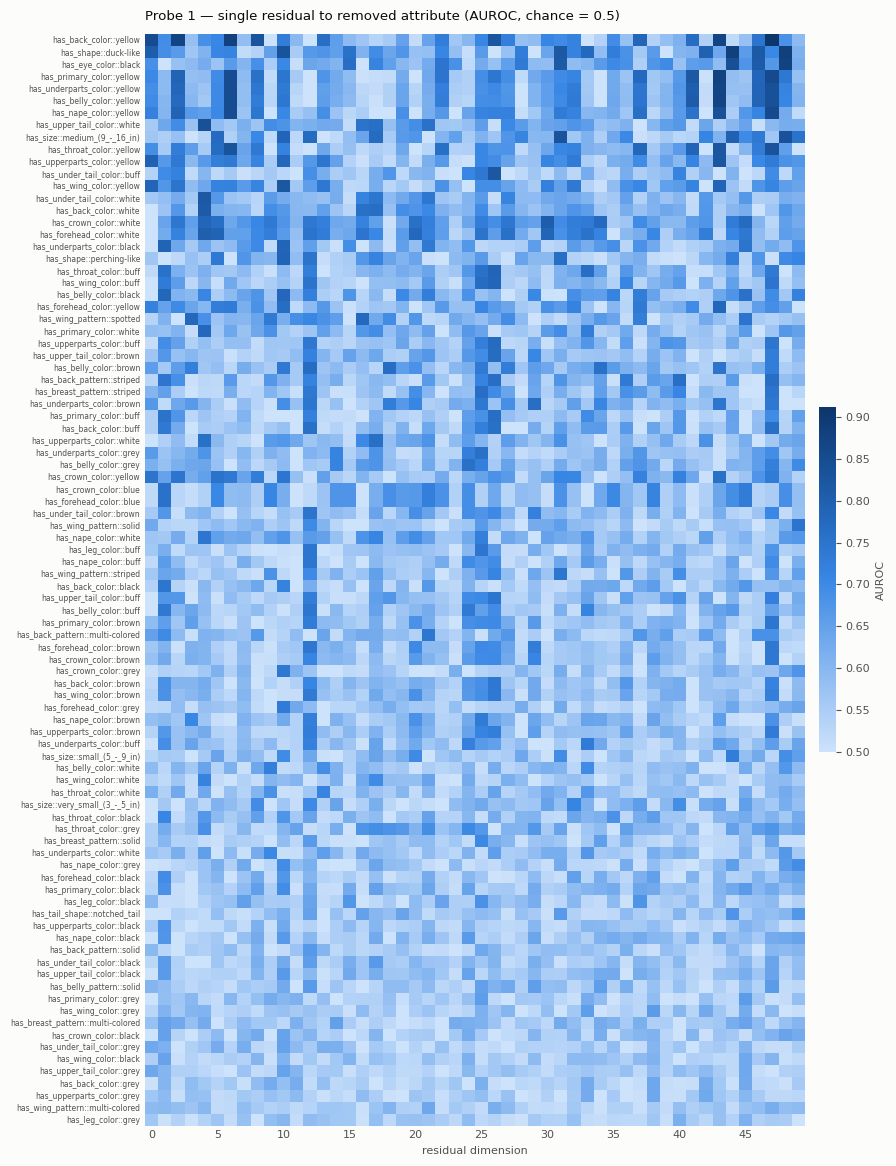

In [10]:
# Probe 1, the raw axis grid: every removed attribute against every residual. Rows are
# ordered by their best residual so any single-dimension structure lands at the top.
grid = single_df.loc[scored["attribute"]].to_numpy()
order = np.argsort(-np.nanmax(grid, axis=1))
grid, row_labels = grid[order], scored["attribute"].to_numpy()[order]

fig, ax = plt.subplots(figsize=(9, max(6, 0.13 * len(grid))))
im = ax.imshow(grid, cmap=SEQ, vmin=0.5, vmax=max(0.75, np.nanmax(grid)), aspect="auto", interpolation="nearest")
ax.set_xlabel("residual dimension")
ax.set_title("Probe 1 — single residual to removed attribute (AUROC, chance = 0.5)", loc="left", pad=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=5.5)
ax.set_xticks(range(0, NUM_RESIDUALS, 5))
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.outline.set_visible(False)
cbar.set_label("AUROC")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "single_residual_auc_heatmap.png"), dpi=200)
plt.show()

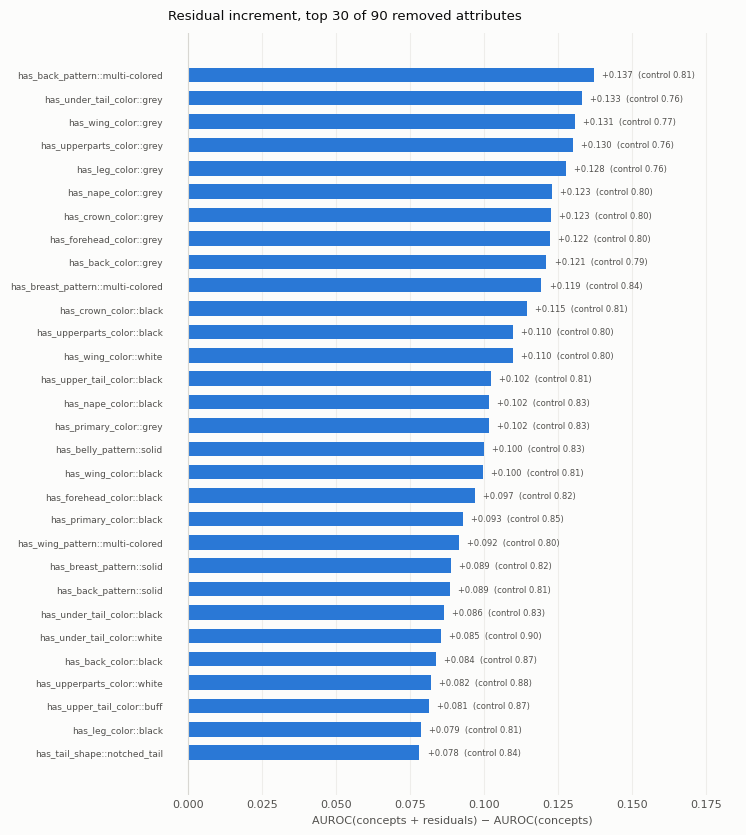

In [11]:
# Probe 4 - probe 3: what the residual channel adds beyond the observed bottleneck.
# Bar length is the magnitude; colour carries only the sign. The control AUROC rides
# along in the direct label, because a +0.13 increment off a 0.76 baseline and off a
# 0.95 baseline are not the same claim.
top = scored.sort_values("residual_increment", ascending=False).head(30).iloc[::-1]
span = float(np.abs(scored["residual_increment"]).max()) or 1e-6

fig, ax = plt.subplots(figsize=(7.5, 0.24 * len(top) + 1.2))
ax.barh(range(len(top)), top["residual_increment"], height=0.62,
        color=[POS if v >= 0 else NEG for v in top["residual_increment"]])
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["attribute"], fontsize=6.5)
ax.axvline(0, color="#d8d7d2", lw=0.8)
ax.set_xlabel("AUROC(concepts + residuals) \u2212 AUROC(concepts)")
ax.set_title(f"Residual increment, top 30 of {len(scored)} removed attributes", loc="left", pad=10)
ax.xaxis.grid(True, color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
for i, (v, c) in enumerate(zip(top["residual_increment"], top["concepts_auc"])):
    ax.text(v + span * 0.02, i, f"{v:+.3f}  (control {c:.2f})", va="center", fontsize=6, color=INK_MUTED)
ax.set_xlim(min(0, top["residual_increment"].min()) - span * 0.05, span * 1.35)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "residual_increment.png"), dpi=200)
plt.show()


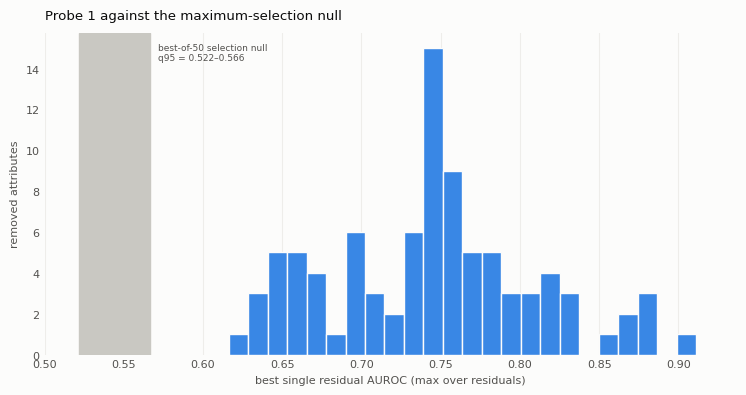

smallest margin over the null: has_leg_color::grey +0.088 (best_single 0.616 vs q95 0.528)


In [12]:
# Probe 1 against its own null. `best_single` is a maximum over NUM_RESIDUALS candidates,
# so the bar to clear is not chance but the max-of-M selection null -- shaded here across
# the range it takes over the attributes (it depends only on each attribute's prevalence).
band_lo = float(scored["null_best_of_M_q95"].min())
band_hi = float(scored["null_best_of_M_q95"].max())
worst = scored.nsmallest(1, "best_minus_null_best").iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.hist(scored["best_single_residual_auc"], bins=24, color="#3987e5",
        edgecolor=SURFACE, linewidth=1.0, zorder=3)
ax.axvspan(band_lo, band_hi, color=RULE, zorder=2)
ax.set_xlim(0.5, float(scored["best_single_residual_auc"].max()) + 0.025)
ymax = ax.get_ylim()[1]
ax.text(band_hi + 0.005, ymax * 0.97,
        f"best-of-{NUM_RESIDUALS} selection null\nq95 = {band_lo:.3f}\u2013{band_hi:.3f}",
        fontsize=6.5, color=INK_MUTED, va="top")
ax.set_xlabel("best single residual AUROC (max over residuals)")
ax.set_ylabel("removed attributes")
ax.set_title("Probe 1 against the maximum-selection null", loc="left", pad=10)
ax.xaxis.grid(True, color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "probe1_vs_null.png"), dpi=200)
plt.show()

print(f"smallest margin over the null: {worst['attribute']} {worst['best_minus_null_best']:+.3f} "
      f"(best_single {worst['best_single_residual_auc']:.3f} vs q95 {worst['null_best_of_M_q95']:.3f})")


## Save

In [13]:
single_df.to_csv(os.path.join(OUT_DIR, "single_residual_auc.csv"))
summary_df.to_csv(os.path.join(OUT_DIR, "attribute_summary.csv"), index=False)
group_df.to_csv(os.path.join(OUT_DIR, "group_summary.csv"), index=False)
print(f"wrote single_residual_auc.csv, attribute_summary.csv, group_summary.csv to {OUT_DIR}")

wrote single_residual_auc.csv, attribute_summary.csv, group_summary.csv to experiments/scbm_residual/CUB/Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02/probes
